# Frozen Lake: Dynamic Programming and Tabular Reinforcement Learning

This notebook implements and compares classical RL methods on the **Frozen Lake** environment
from [Gymnasium](https://gymnasium.farama.org/). All algorithms are implemented from scratch
using NumPy.

**Algorithms covered:**
- Policy Evaluation (iterative)
- Policy Improvement (greedy)
- Policy Iteration
- Value Iteration
- Q-Learning (model-free)

**Environments:**
- Standard 4×4 Frozen Lake (deterministic and stochastic/slippery variants)
- Custom narrow corridor map

This notebook is part of a research project originally presented at Student Research Day
at Kean University. The original poster is preserved in `docs/frozen_lake_challenge.pdf`.

## 1. Setup and Imports

In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import pandas as pd
import warnings
import os
from gymnasium.envs.toy_text.frozen_lake import FrozenLakeEnv

warnings.filterwarnings("ignore")

SEED = 42
RESULTS_DIR = os.path.join("..", "results")
FIGURES_DIR = os.path.join(RESULTS_DIR, "figures")
TABLES_DIR  = os.path.join(RESULTS_DIR, "tables")
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR,  exist_ok=True)

print(f"numpy  {np.__version__}")
print(f"gymnasium {gym.__version__}")
print(f"Results will be saved to: {os.path.abspath(RESULTS_DIR)}")

numpy  2.4.6
gymnasium 1.3.0
Results will be saved to: /Users/bellamac/Desktop/frozen-lake-reinforcement-learning/results


## 2. Custom Environment

The standard Frozen Lake gives reward 0 for falling into a hole and reward +1 for reaching
the goal. We add a **−1 penalty for holes** to give the agent a clearer signal to avoid
them — this matches the setup used in the original Student Research Day poster.

In [2]:
class CustomFrozenLakeEnv(FrozenLakeEnv):
    """FrozenLake with a configurable negative reward for falling into a hole."""

    def __init__(self, hole_penalty=-1.0, **kwargs):
        super().__init__(**kwargs)
        self.hole_penalty = hole_penalty

    def step(self, action):
        obs, reward, terminated, truncated, info = super().step(action)
        # terminated=True and reward=0 means the agent fell into a hole
        if terminated and reward == 0:
            reward = self.hole_penalty
        return obs, reward, terminated, truncated, info


# Quick smoke test
_env = CustomFrozenLakeEnv(desc=["SF", "HG"], is_slippery=False)
print(f"States: {_env.observation_space.n}, Actions: {_env.action_space.n}")
print("Custom environment ready.")

States: 4, Actions: 4
Custom environment ready.


## 3. Dynamic Programming

Dynamic programming (DP) methods require a **known model** — the full transition function
`P[s][a] = [(probability, next_state, reward, done), ...]`.  
Gymnasium exposes this via `env.P` for toy environments.

> **Gamma = 0.9** is used throughout to balance immediate vs. future rewards.

### 3.1 Policy Evaluation

Iteratively apply the Bellman expectation equation until the value function converges:

$$V(s) \leftarrow \sum_{s'} P(s' \mid s, \pi(s))\bigl[R(s,\pi(s),s') + \gamma V(s')\bigr]$$

In [3]:
def policy_evaluation(P, nS, nA, policy, gamma=0.9, tol=1e-3):
    """Evaluate a policy by iterating the Bellman expectation equation.

    Args:
        P    : Transition model — P[s][a] = [(prob, s', r, done), ...]
        nS   : Number of states
        nA   : Number of actions
        policy: Array mapping state → action, shape (nS,)
        gamma: Discount factor
        tol  : Convergence threshold on max|V_new - V|

    Returns:
        V: Value function array, shape (nS,)
    """
    V = np.zeros(nS)
    while True:
        V_new = np.zeros(nS)
        for s in range(nS):
            a = policy[s]
            for prob, s_next, r, _ in P[s][a]:
                V_new[s] += prob * (r + gamma * V[s_next])
        if np.max(np.abs(V_new - V)) < tol:
            return V_new
        V = V_new

### 3.2 Policy Improvement

Given a value function $V$, compute the greedy policy:

$$\pi'(s) = \arg\max_a \sum_{s'} P(s'\mid s,a)\bigl[R(s,a,s') + \gamma V(s')\bigr]$$

In [4]:
def policy_improvement(P, nS, nA, V, gamma=0.9):
    """Return the greedy policy with respect to value function V.

    Args:
        P    : Transition model
        nS, nA: State and action counts
        V    : Value function to improve upon, shape (nS,)
        gamma: Discount factor

    Returns:
        policy: Greedy policy array, shape (nS,)
    """
    policy = np.zeros(nS, dtype=int)
    for s in range(nS):
        Q_s = np.zeros(nA)
        for a in range(nA):
            for prob, s_next, r, _ in P[s][a]:
                Q_s[a] += prob * (r + gamma * V[s_next])
        policy[s] = np.argmax(Q_s)
    return policy

### 3.3 Policy Iteration

Alternate between **policy evaluation** and **policy improvement** until the policy stops changing.

In [5]:
def policy_iteration(P, nS, nA, gamma=0.9, tol=1e-3):
    """Find the optimal policy by alternating evaluation and improvement.

    Args:
        P    : Transition model
        nS, nA: State and action counts
        gamma: Discount factor
        tol  : Convergence tolerance passed to policy_evaluation

    Returns:
        V      : Converged value function
        policy : Optimal policy
        n_iters: Number of policy improvement steps
    """
    V = np.zeros(nS)
    policy = np.zeros(nS, dtype=int)
    n_iters = 0

    while True:
        V = policy_evaluation(P, nS, nA, policy, gamma, tol)
        new_policy = policy_improvement(P, nS, nA, V, gamma)
        n_iters += 1
        if np.array_equal(new_policy, policy):
            break
        policy = new_policy

    return V, policy, n_iters

### 3.4 Value Iteration

Apply Bellman **optimality** backups directly, bypassing the separate evaluation step:

$$V_{k+1}(s) = \max_a \sum_{s'} P(s'\mid s,a)\bigl[R(s,a,s') + \gamma V_k(s')\bigr]$$

In [6]:
def value_iteration(P, nS, nA, gamma=0.9, tol=1e-3):
    """Compute the optimal value function via Bellman optimality backups.

    Args:
        P    : Transition model
        nS, nA: State and action counts
        gamma: Discount factor
        tol  : Convergence threshold on max|V_new - V|

    Returns:
        V      : Optimal value function
        policy : Greedy policy derived from V
        n_iters: Number of full Bellman sweep iterations
    """
    V = np.zeros(nS)
    n_iters = 0

    while True:
        V_new = np.zeros(nS)
        for s in range(nS):
            Q_s = np.zeros(nA)
            for a in range(nA):
                for prob, s_next, r, _ in P[s][a]:
                    Q_s[a] += prob * (r + gamma * V[s_next])
            V_new[s] = np.max(Q_s)
        n_iters += 1
        if np.max(np.abs(V_new - V)) < tol:
            V = V_new
            break
        V = V_new

    policy = policy_improvement(P, nS, nA, V, gamma)
    return V, policy, n_iters

## 4. Model-Free RL: Q-Learning

Q-learning learns action-values from environment interaction **without needing the model**.
An ε-greedy policy is used for exploration, with ε decaying each episode.

Update rule:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\bigl[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\bigr]$$

In [7]:
def q_learning(
    env, nS, nA,
    gamma=0.9,
    alpha=0.5,
    epsilon_start=1.0,
    epsilon_min=0.01,
    decay=0.995,
    epochs=3000,
    max_steps=200,
    seed=42,
):
    """Tabular Q-learning with epsilon-greedy exploration.

    Args:
        env          : Gymnasium environment
        nS, nA       : State and action counts
        gamma        : Discount factor
        alpha        : Learning rate
        epsilon_start: Initial exploration rate
        epsilon_min  : Floor on epsilon (prevents fully greedy policy during training)
        decay        : Per-episode epsilon multiplier
        epochs       : Number of training episodes
        max_steps    : Max steps per episode
        seed         : RNG seed for reproducibility

    Returns:
        Q              : Q-value table, shape (nS, nA)
        policy         : Greedy policy derived from Q, shape (nS,)
        episode_rewards: Per-episode total rewards (list of length `epochs`)
    """
    rng_q = np.random.default_rng(seed)
    Q = np.zeros([nS, nA])
    epsilon = epsilon_start
    episode_rewards = []

    for _ in range(epochs):
        s, _ = env.reset(seed=int(rng_q.integers(1_000_000)))
        ep_reward = 0.0
        epsilon = max(epsilon * decay, epsilon_min)

        for _ in range(max_steps):
            if rng_q.random() > epsilon:
                a = int(np.argmax(Q[s]))
            else:
                a = int(rng_q.integers(nA))

            s_next, r, terminated, truncated, _ = env.step(a)
            Q[s, a] += alpha * (r + gamma * np.max(Q[s_next]) - Q[s, a])
            ep_reward += r
            s = s_next
            if terminated or truncated:
                break

        episode_rewards.append(ep_reward)

    policy = np.array([int(np.argmax(Q[s])) for s in range(nS)])
    return Q, policy, episode_rewards

## 5. Evaluation and Visualization Utilities

In [8]:
ACTION_ARROWS = {0: "←", 1: "↓", 2: "→", 3: "↑"}

CELL_COLORS = {
    "S": "#a8d8a8",   # start  - green
    "F": "#d0e8f0",   # frozen - blue
    "H": "#f08080",   # hole   - red
    "G": "#ffd700",   # goal   - gold
}


def get_map_desc(env):
    """Return the grid layout as a list of strings."""
    rows = env.unwrapped.desc
    if rows.dtype.kind == "S":
        return ["".join(c.decode() for c in row) for row in rows]
    return ["".join(row) for row in rows]


def evaluate_policy(env, policy, n_episodes=1000, max_steps=200, seed=0):
    """Run a greedy policy for n_episodes and report success rate and mean reward.

    Success is defined as any episode with total reward > 0 (i.e., reached the goal).

    Returns:
        success_rate: float in [0, 1]
        mean_reward : float
    """
    rng_eval = np.random.default_rng(seed)
    successes = 0
    total_reward = 0.0

    for _ in range(n_episodes):
        obs, _ = env.reset(seed=int(rng_eval.integers(1_000_000)))
        ep_reward = 0.0
        for _ in range(max_steps):
            a = int(policy[obs])
            obs, r, terminated, truncated, _ = env.step(a)
            ep_reward += r
            if terminated or truncated:
                break
        total_reward += ep_reward
        if ep_reward > 0:
            successes += 1

    return successes / n_episodes, total_reward / n_episodes


def plot_value_function(V, desc, title="Value Function", ax=None, save_path=None):
    """Heatmap of the value function overlaid on the grid layout."""
    nrow, ncol = len(desc), len(desc[0])
    grid = V.reshape(nrow, ncol)

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(ncol * 1.6, nrow * 1.6))
    else:
        fig = ax.get_figure()

    vmax = max(grid.max(), 0.01)
    im = ax.imshow(grid, cmap="RdYlGn", vmin=grid.min(), vmax=vmax, aspect="equal")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for r in range(nrow):
        for c in range(ncol):
            cell = desc[r][c]
            txt_color = "white" if grid[r, c] > 0.6 * vmax else "black"
            ax.text(c, r, f"{grid[r, c]:.2f}\n({cell})",
                    ha="center", va="center", fontsize=9, color=txt_color)

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig


def plot_policy(policy, desc, title="Learned Policy", ax=None, save_path=None):
    """Render the policy as directional arrows on a color-coded grid."""
    nrow, ncol = len(desc), len(desc[0])

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(ncol * 1.6, nrow * 1.6))
    else:
        fig = ax.get_figure()

    for r in range(nrow):
        for c in range(ncol):
            cell = desc[r][c]
            color = CELL_COLORS.get(cell, "white")
            rect = plt.Rectangle([c, nrow - r - 1], 1, 1,
                                  color=color, ec="gray", lw=0.8)
            ax.add_patch(rect)
            s = r * ncol + c
            ax.text(c + 0.5, nrow - r - 0.5, ACTION_ARROWS[int(policy[s])],
                    ha="center", va="center", fontsize=18)

    ax.set_xlim(0, ncol)
    ax.set_ylim(0, nrow)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=11, fontweight="bold")

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig


def plot_learning_curve(rewards, window=100, title="Q-Learning Reward Curve",
                        ax=None, save_path=None):
    """Smoothed episode reward curve with a moving-average overlay."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 4))
    else:
        fig = ax.get_figure()

    smoothed = np.convolve(rewards, np.ones(window) / window, mode="valid")
    ax.plot(rewards, alpha=0.25, color="steelblue", linewidth=0.8, label="episode reward")
    ax.plot(range(window - 1, len(rewards)), smoothed,
            color="steelblue", linewidth=2, label=f"{window}-ep moving avg")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Total Reward")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend()
    ax.grid(True, alpha=0.3)

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig


print("Utilities loaded.")

Utilities loaded.


## 6. Experiments: Standard 4×4 Frozen Lake

We use the canonical 4×4 map with both **non-slippery** (deterministic) and **slippery**
(stochastic — 1/3 probability each of intended and two perpendicular directions) variants.

```
S F F F      S = Start
F H F H      F = Frozen
F F F H      H = Hole  (−1 penalty in custom env)
H F F G      G = Goal  (+1 reward)
```

In [9]:
MAP_4x4 = ["SFFF", "FHFH", "FFFH", "HFFG"]

# Model environments (needed for DP — they expose env.P)
env_det  = CustomFrozenLakeEnv(desc=MAP_4x4, is_slippery=False)
env_slip = CustomFrozenLakeEnv(desc=MAP_4x4, is_slippery=True)

nS = env_det.observation_space.n
nA = env_det.action_space.n
P_det  = env_det.P
P_slip = env_slip.P

desc_4x4 = get_map_desc(env_det)

print(f"States: {nS}  |  Actions: {nA}  |  Action map: 0=← 1=↓ 2=→ 3=↑")
print("Map:")
for row in desc_4x4:
    print(" ", " ".join(row))

States: 16  |  Actions: 4  |  Action map: 0=← 1=↓ 2=→ 3=↑
Map:
  S F F F
  F H F H
  F F F H
  H F F G


### 6.1 Run Dynamic Programming Algorithms

In [10]:
# Policy Iteration
V_pi_det,  pi_pi_det,  n_pi_det  = policy_iteration(P_det,  nS, nA, gamma=0.9)
V_pi_slip, pi_pi_slip, n_pi_slip = policy_iteration(P_slip, nS, nA, gamma=0.9)

print("Policy Iteration")
print(f"  Non-slippery: {n_pi_det} improvement step(s)")
print(f"  Slippery    : {n_pi_slip} improvement step(s)")

print("\nNon-slippery policy (actions):")
print([[ACTION_ARROWS[a] for a in row] for row in pi_pi_det.reshape(4, 4)])

print("\nSlippery policy (actions):")
print([[ACTION_ARROWS[a] for a in row] for row in pi_pi_slip.reshape(4, 4)])

Policy Iteration
  Non-slippery: 7 improvement step(s)
  Slippery    : 6 improvement step(s)

Non-slippery policy (actions):
[['↓', '→', '↓', '←'], ['↓', '←', '↓', '←'], ['→', '↓', '↓', '←'], ['←', '→', '→', '←']]

Slippery policy (actions):
[['←', '↑', '←', '↑'], ['←', '←', '←', '←'], ['↑', '↓', '←', '←'], ['←', '→', '↓', '←']]


In [11]:
# Value Iteration
V_vi_det,  pi_vi_det,  n_vi_det  = value_iteration(P_det,  nS, nA, gamma=0.9)
V_vi_slip, pi_vi_slip, n_vi_slip = value_iteration(P_slip, nS, nA, gamma=0.9)

print("Value Iteration")
print(f"  Non-slippery: {n_vi_det} Bellman sweep(s)")
print(f"  Slippery    : {n_vi_slip} Bellman sweep(s)")

print("\nNon-slippery policy (actions):")
print([[ACTION_ARROWS[a] for a in row] for row in pi_vi_det.reshape(4, 4)])

print("\nSlippery policy (actions):")
print([[ACTION_ARROWS[a] for a in row] for row in pi_vi_slip.reshape(4, 4)])

Value Iteration
  Non-slippery: 7 Bellman sweep(s)
  Slippery    : 27 Bellman sweep(s)

Non-slippery policy (actions):
[['↓', '→', '↓', '←'], ['↓', '←', '↓', '←'], ['→', '↓', '↓', '←'], ['←', '→', '→', '←']]

Slippery policy (actions):
[['←', '↑', '←', '↑'], ['←', '←', '←', '←'], ['↑', '↓', '←', '←'], ['←', '→', '↓', '←']]


### 6.2 Run Q-Learning

In [12]:
# Train Q-learning on non-slippery map
env_ql_det = CustomFrozenLakeEnv(desc=MAP_4x4, is_slippery=False)
Q_det, pi_ql_det, rewards_det = q_learning(
    env_ql_det, nS, nA,
    gamma=0.9, alpha=0.5,
    epsilon_start=1.0, epsilon_min=0.01, decay=0.995,
    epochs=3000, max_steps=200, seed=SEED,
)

# Train Q-learning on slippery map (needs more episodes due to stochasticity)
env_ql_slip = CustomFrozenLakeEnv(desc=MAP_4x4, is_slippery=True)
Q_slip, pi_ql_slip, rewards_slip = q_learning(
    env_ql_slip, nS, nA,
    gamma=0.9, alpha=0.5,
    epsilon_start=1.0, epsilon_min=0.01, decay=0.997,
    epochs=6000, max_steps=200, seed=SEED,
)

print("Q-Learning training complete.")
print("Non-slippery policy:")
print([[ACTION_ARROWS[a] for a in row] for row in pi_ql_det.reshape(4, 4)])
print("Slippery policy:")
print([[ACTION_ARROWS[a] for a in row] for row in pi_ql_slip.reshape(4, 4)])

Q-Learning training complete.
Non-slippery policy:
[['↓', '←', '←', '←'], ['↓', '←', '↓', '←'], ['→', '↓', '←', '←'], ['←', '→', '→', '←']]
Slippery policy:
[['↑', '↑', '↑', '↑'], ['←', '←', '←', '←'], ['↑', '↓', '←', '←'], ['←', '→', '↓', '←']]


## 7. Visualizations

Figures are saved to `results/figures/` for inclusion in reports or the portfolio.

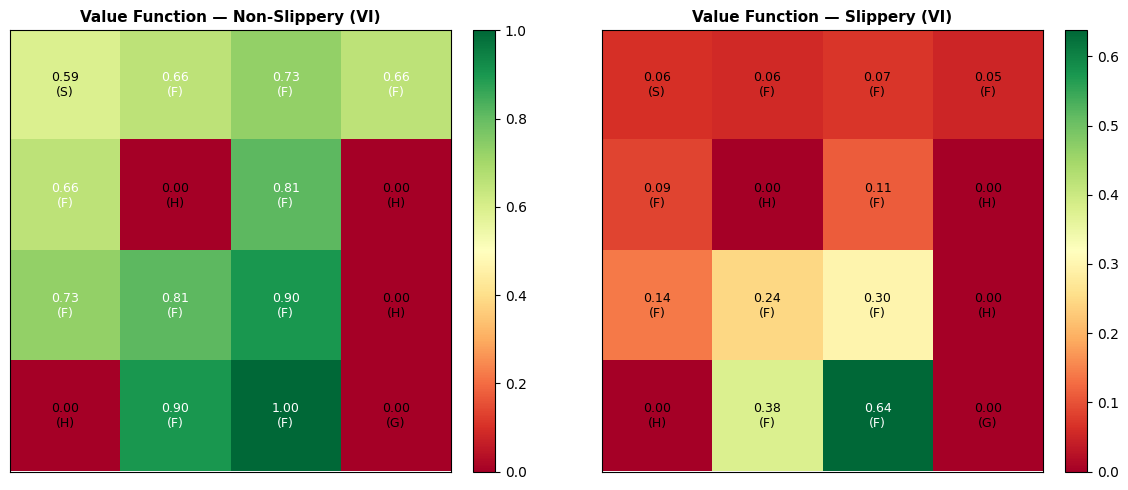

Saved: ../results/figures/value_function_heatmap.png


In [13]:
# Value function heatmaps (Value Iteration)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_value_function(V_vi_det,  desc_4x4, "Value Function — Non-Slippery (VI)", ax=axes[0])
plot_value_function(V_vi_slip, desc_4x4, "Value Function — Slippery (VI)",     ax=axes[1])
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, "value_function_heatmap.png")
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

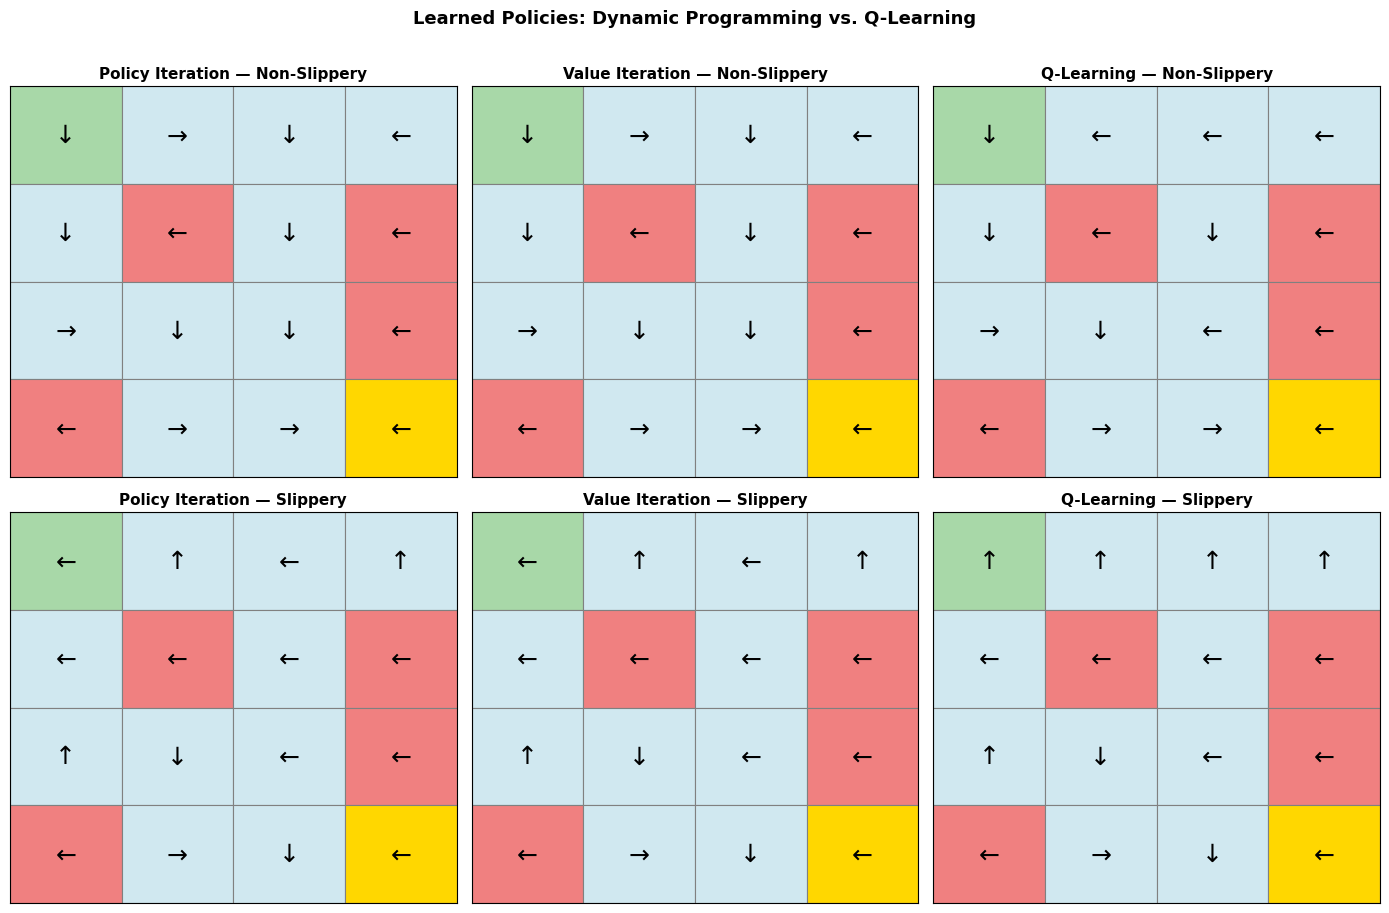

Saved: ../results/figures/policy_comparison_grid.png


In [14]:
# Policy grids: all three algorithms, both environments
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

plot_policy(pi_pi_det,  desc_4x4, "Policy Iteration — Non-Slippery", ax=axes[0, 0])
plot_policy(pi_vi_det,  desc_4x4, "Value Iteration — Non-Slippery",  ax=axes[0, 1])
plot_policy(pi_ql_det,  desc_4x4, "Q-Learning — Non-Slippery",       ax=axes[0, 2])

plot_policy(pi_pi_slip, desc_4x4, "Policy Iteration — Slippery", ax=axes[1, 0])
plot_policy(pi_vi_slip, desc_4x4, "Value Iteration — Slippery",  ax=axes[1, 1])
plot_policy(pi_ql_slip, desc_4x4, "Q-Learning — Slippery",       ax=axes[1, 2])

plt.suptitle("Learned Policies: Dynamic Programming vs. Q-Learning",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, "policy_comparison_grid.png")
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

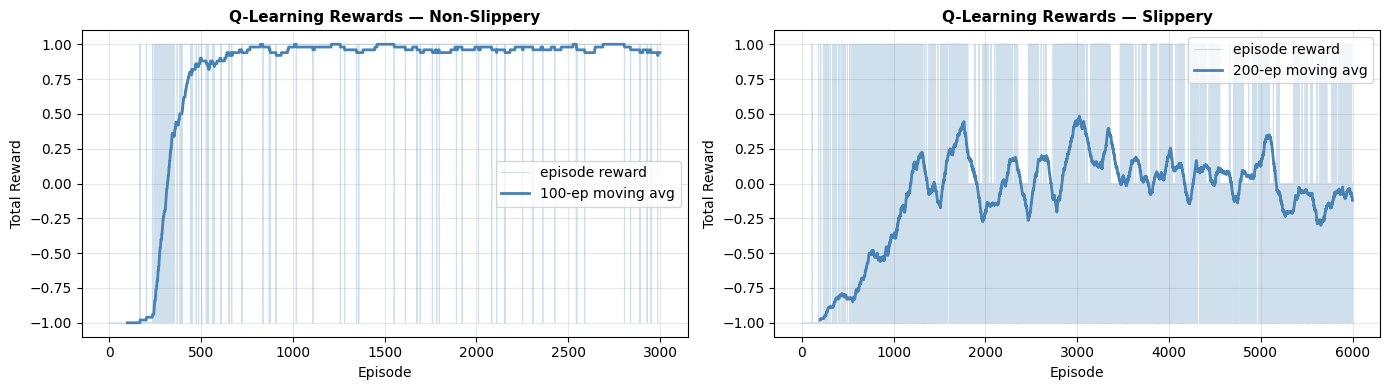

Saved: ../results/figures/q_learning_reward_curve.png


In [15]:
# Q-learning reward curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_learning_curve(rewards_det,  window=100, title="Q-Learning Rewards — Non-Slippery", ax=axes[0])
plot_learning_curve(rewards_slip, window=200, title="Q-Learning Rewards — Slippery",     ax=axes[1])
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, "q_learning_reward_curve.png")
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

## 8. Results Summary

Evaluate all policies over 1,000 episodes and compare success rate and mean reward.

> Results vary slightly with random seed and environment stochasticity.

In [16]:
N_EVAL = 1000

eval_env_det  = CustomFrozenLakeEnv(desc=MAP_4x4, is_slippery=False)
eval_env_slip = CustomFrozenLakeEnv(desc=MAP_4x4, is_slippery=True)

results = []
for algo, pi_d, pi_s in [
    ("Policy Iteration", pi_pi_det, pi_pi_slip),
    ("Value Iteration",  pi_vi_det, pi_vi_slip),
    ("Q-Learning",       pi_ql_det, pi_ql_slip),
]:
    sr_d, mr_d = evaluate_policy(eval_env_det,  pi_d, N_EVAL)
    sr_s, mr_s = evaluate_policy(eval_env_slip, pi_s, N_EVAL)
    results.append({"Algorithm": algo, "Env": "Non-Slippery",
                    "Success Rate": sr_d, "Mean Reward": mr_d})
    results.append({"Algorithm": algo, "Env": "Slippery",
                    "Success Rate": sr_s, "Mean Reward": mr_s})

df = pd.DataFrame(results)
df_display = df.copy()
df_display["Success Rate"] = df_display["Success Rate"].map("{:.1%}".format)
df_display["Mean Reward"]  = df_display["Mean Reward"].map("{:.3f}".format)
print(df_display.to_string(index=False))

csv_path = os.path.join(TABLES_DIR, "algorithm_comparison.csv")
df.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")

       Algorithm          Env Success Rate Mean Reward
Policy Iteration Non-Slippery       100.0%       1.000
Policy Iteration     Slippery        76.0%       0.523
 Value Iteration Non-Slippery       100.0%       1.000
 Value Iteration     Slippery        76.0%       0.523
      Q-Learning Non-Slippery       100.0%       1.000
      Q-Learning     Slippery         0.0%       0.000

Saved: ../results/tables/algorithm_comparison.csv


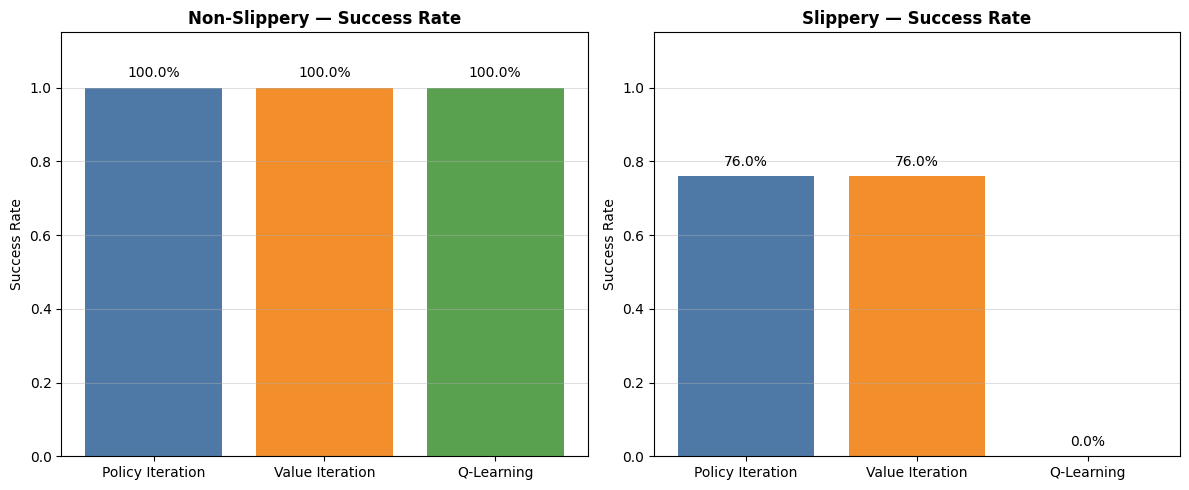

Saved: ../results/figures/algorithm_comparison_bar.png


In [17]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, env_label, metric in [
    (axes[0], "Non-Slippery", "Success Rate"),
    (axes[1], "Slippery",     "Success Rate"),
]:
    subset = df[df["Env"] == env_label]
    bars = ax.bar(subset["Algorithm"], subset["Success Rate"],
                  color=["#4e79a7", "#f28e2b", "#59a14f"])
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Success Rate")
    ax.set_title(f"{env_label} — Success Rate", fontweight="bold")
    ax.grid(axis="y", alpha=0.4)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{bar.get_height():.1%}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, "algorithm_comparison_bar.png")
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

## 9. Custom Map Experiment

The narrow corridor map below was used in the original Student Research Day poster to
illustrate policy learning in a tightly constrained environment:

```
H H H H H
H S F F G
H H H H H
```

The only viable path is moving right along the single open row.

In [18]:
CUSTOM_MAP = ["HHHHH", "HSFFG", "HHHHH"]

env_custom = CustomFrozenLakeEnv(desc=CUSTOM_MAP, is_slippery=False)
nS_c = env_custom.observation_space.n
nA_c = env_custom.action_space.n
P_c  = env_custom.P
desc_c = get_map_desc(env_custom)

# Dynamic Programming
V_c, pi_vi_c, n_c = value_iteration(P_c, nS_c, nA_c, gamma=0.9)
print(f"Value Iteration on custom map: {n_c} sweeps")
print("Policy:")
print([[ACTION_ARROWS[a] for a in row] for row in pi_vi_c.reshape(3, 5)])

# Q-Learning
env_custom_ql = CustomFrozenLakeEnv(desc=CUSTOM_MAP, is_slippery=False)
Q_c, pi_ql_c, rewards_c = q_learning(
    env_custom_ql, nS_c, nA_c,
    gamma=0.9, alpha=0.5, decay=0.99,
    epochs=1000, max_steps=20, seed=SEED,
)
print("\nQ-Learning policy:")
print([[ACTION_ARROWS[a] for a in row] for row in pi_ql_c.reshape(3, 5)])

Value Iteration on custom map: 4 sweeps
Policy:
[['←', '←', '←', '←', '←'], ['←', '→', '→', '→', '←'], ['←', '←', '←', '←', '←']]

Q-Learning policy:
[['←', '←', '←', '←', '←'], ['←', '→', '→', '→', '←'], ['←', '←', '←', '←', '←']]


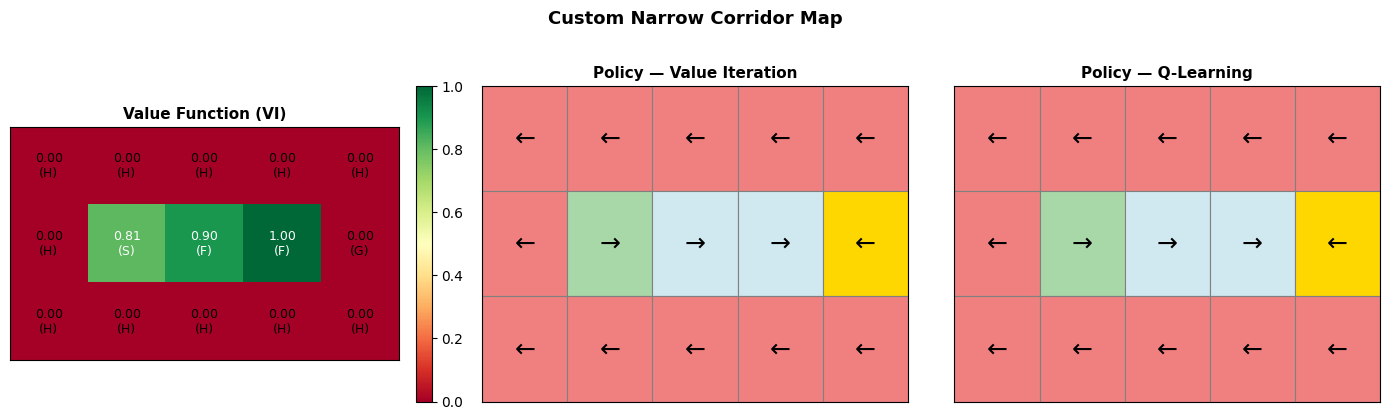

Saved: ../results/figures/custom_map_results.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_value_function(V_c,     desc_c, "Value Function (VI)",   ax=axes[0])
plot_policy(pi_vi_c, desc_c, "Policy — Value Iteration", ax=axes[1])
plot_policy(pi_ql_c, desc_c, "Policy — Q-Learning",      ax=axes[2])
plt.suptitle("Custom Narrow Corridor Map", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, "custom_map_results.png")
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

## 10. Discussion and Limitations

### Key Observations

- **Policy Iteration and Value Iteration** both converge to the same optimal policy when
  the full model is known. They differ mainly in computational structure: Policy Iteration
  runs a full evaluation pass each iteration; Value Iteration runs a single Bellman sweep.

- **Q-Learning** does not require knowledge of `P[s][a]` and matches the DP policies on
  the non-slippery variant. On the slippery variant, learned policies depend on the number
  of training episodes and the exploration schedule.

- The **slippery environment** is significantly harder: even an optimal policy cannot
  guarantee reaching the goal due to uncontrollable lateral slips. Success rates below 100%
  on the slippery variant are expected and not a failure of the algorithm.

- The **hole penalty (−1)** helps model-free methods learn faster by providing a denser
  negative signal. DP methods are not affected since they use the model directly.

### Limitations

- Frozen Lake is a small tabular environment. Results do not generalize directly to
  high-dimensional problems where function approximation is required.
- Q-Learning results are sensitive to the exploration schedule (epsilon, decay) and
  learning rate (alpha). No systematic hyperparameter sweep was performed.
- SARSA (on-policy TD) was not implemented; it would be an interesting comparison.

### Possible Next Steps

- Systematic hyperparameter grid search for Q-Learning (alpha, gamma, epsilon decay)
- Multi-seed evaluation with confidence intervals
- SARSA implementation for on-policy vs. off-policy comparison
- Larger randomly generated maps (`generate_random_map(size=8)`)
- Deep Q-Network (DQN) as a future extension to handle larger state spaces